# Brazilian E-Commerce by Olist 🛒 - 데이터 분석 & 예측 모델링 프로젝트

이 프로젝트는 브라질 전자상거래 플랫폼 Olist의 데이터에 대해 탐색적 데이터 분석(EDA)을 수행하고, 비즈니스 성과에 영향을 주는 주요 요인을 파악하는 것을 목표로 합니다. 통계적 인사이트와 비즈니스 관점의 결론을 함께 도출합니다.


## 🎯 비즈니스 문제

- *Olist는 여러 판매자와 브라질 전역의 고객을 연결하는 온라인 마켓플레이스입니다.*
- *이 회사는 배송 지연이라는 문제에 직면해 있습니다.*
- *배송이 늦어지면 고객 만족도와 리뷰 점수가 떨어지며, 결국 이탈률이 높아집니다. 심지어 전반적인 매출과 브랜드 평판에 타격을 줄 수도 있습니다.*
- ***Olist는 어떻게 이 문제를 해결하고 고객의 신뢰를 회복할 수 있을까요?***


# 1️⃣ Importing Library

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2️⃣ Loading Datasets

In [19]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/olist_data'

df_customer = pd.read_csv(f'{BASE_PATH}/olist_customers_dataset.csv')
df_location = pd.read_csv(f'{BASE_PATH}/olist_geolocation_dataset.csv')
df_order_items = pd.read_csv(f'{BASE_PATH}/olist_order_items_dataset.csv')
df_order_payment = pd.read_csv(f'{BASE_PATH}/olist_order_payments_dataset.csv')
df_order_review = pd.read_csv(f'{BASE_PATH}/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv(f'{BASE_PATH}/olist_orders_dataset.csv')
df_products = pd.read_csv(f'{BASE_PATH}/olist_products_dataset.csv')
df_translation = pd.read_csv(f'{BASE_PATH}/product_category_name_translation.csv')
df_sellers = pd.read_csv(f'{BASE_PATH}/olist_sellers_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3️⃣ Data Clean



### 3.1 Customer Dataset

In [20]:
df_customer.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [21]:
df_customer.duplicated().sum()

np.int64(0)

/tmp/ipykernel_12463/1912939728.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




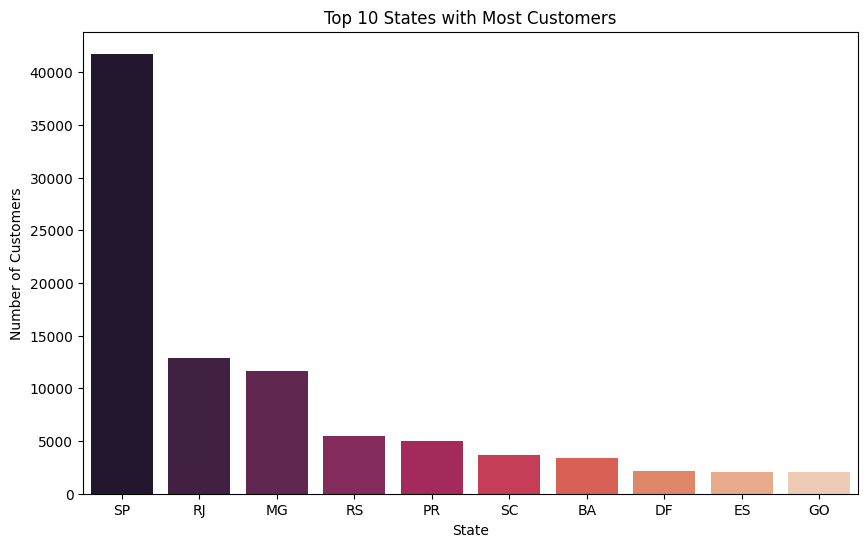

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_customer['customer_state'].value_counts().head(10).index,
            y=df_customer['customer_state'].value_counts().head(10).values, palette='rocket')
plt.title('Top 10 States with Most Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

### 3.2 Products Dataset


In [23]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


- `df translation`과 left join으로 포르투갈어 카테고리명을 영어로 변환합니다.
- 번역 없는 항목은 Unknown으로 대체합니다.

In [24]:
df_products_eng = df_products.merge(df_translation, on='product_category_name', how='left')
df_products_eng['product_category_name_english'] = df_products_eng['product_category_name_english'].fillna('Unknown')

In [25]:
df_products_eng.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2
product_category_name_english,0


In [26]:
cols = [
    'product_category_name',
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
]

df_products_eng[df_products_eng[cols].isnull().any(axis=1)].head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0,Unknown
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0,Unknown
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0,Unknown
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0,Unknown
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0,Unknown
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0,Unknown
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0,Unknown
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0,Unknown
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0,Unknown
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0,Unknown


In [27]:
df_products_eng = df_products_eng.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'])

In [28]:
df_products_eng.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1
product_category_name_english,0


/tmp/ipykernel_12463/2079311773.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




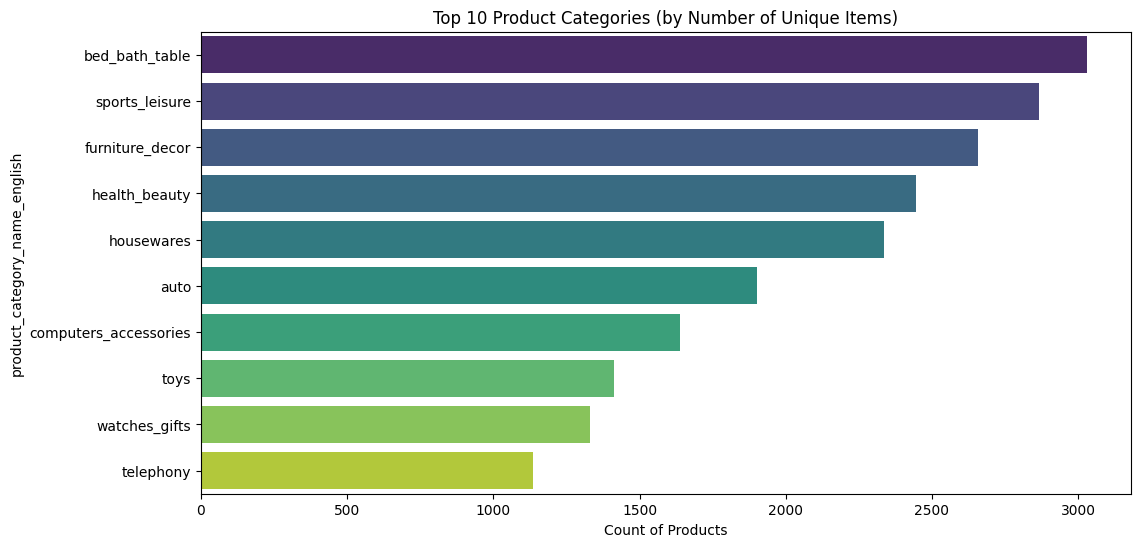

In [29]:
plt.figure(figsize=(12, 6))
top_categories = df_products_eng['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Product Categories (by Number of Unique Items)')
plt.xlabel('Count of Products')
plt.show()

### 3.3 Sellers Dataset

In [30]:
df_sellers.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [31]:
df_sellers.duplicated().sum()

np.int64(0)

/tmp/ipykernel_12463/134741640.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




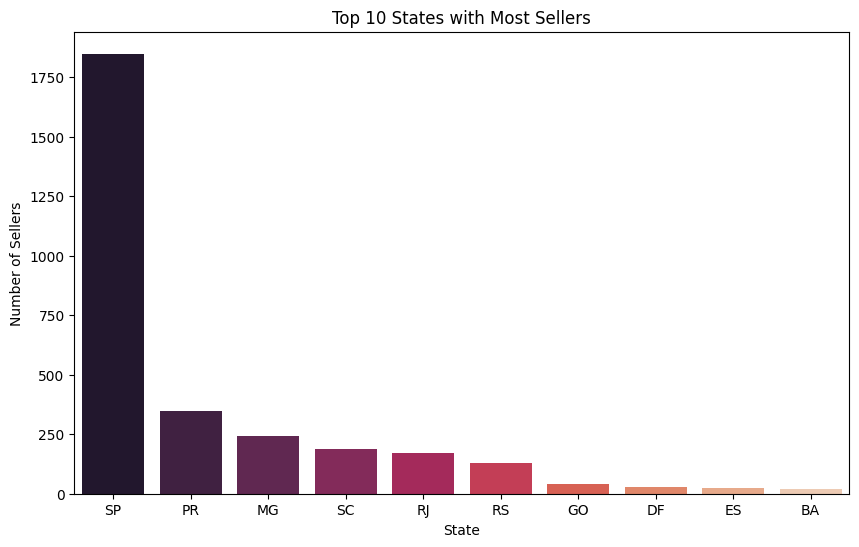

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_sellers['seller_state'].value_counts().head(10).index,
            y=df_sellers['seller_state'].value_counts().head(10).values, palette='rocket')
plt.title('Top 10 States with Most Sellers')
plt.xlabel('State')
plt.ylabel('Number of Sellers')
plt.show()

### 3.4 Order Itmes Dataset

In [33]:
df_order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [34]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [35]:
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

In [36]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [37]:
df_order_items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [38]:
# df_order_items에서 order_id가 두 번 이상 나타나는 order_id 식별
duplicate_order_ids_in_items = df_order_items['order_id'].value_counts()
duplicate_order_ids_in_items = duplicate_order_ids_in_items[duplicate_order_ids_in_items > 1].index

# 식별된 order_id를 가진 모든 행을 df_order_items에서 필터링
duplicated_rows = df_order_items[df_order_items['order_id'].isin(duplicate_order_ids_in_items)]

if not duplicate_order_ids_in_items.empty:
    print(f"'df_order_items'에서 2번 이상 나타나는 고유한 order_id 수: {len(duplicate_order_ids_in_items)}")
    print(f"'df_order_items'에서 2번 이상 나타나는 order_id에 해당하는 총 행의 수: {len(duplicated_rows)}")
    display(duplicated_rows.sort_values(by='order_id').head(50))
else:
    print("'df_order_items'에 2번 이상 나타나는 order_id는 없습니다.")

'df_order_items'에서 2번 이상 나타나는 고유한 order_id 수: 9803
'df_order_items'에서 2번 이상 나타나는 order_id에 해당하는 총 행의 수: 23787


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
42,001ab0a7578dd66cd4b0a71f5b6e1e41,1,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
43,001ab0a7578dd66cd4b0a71f5b6e1e41,2,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
44,001ab0a7578dd66cd4b0a71f5b6e1e41,3,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
49,001d8f0e34a38c37f7dba2a37d4eba8b,2,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78
48,001d8f0e34a38c37f7dba2a37d4eba8b,1,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78


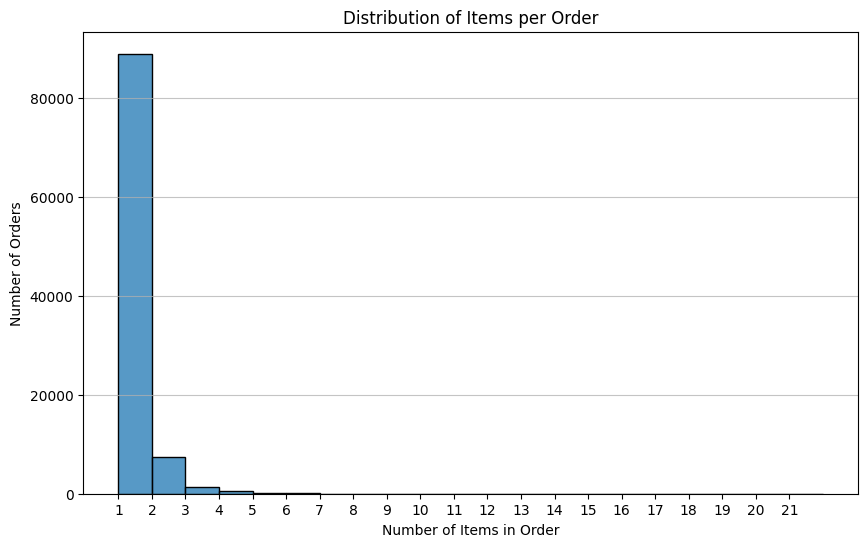

,item_count,order_count
0,1,88863
1,2,7516
2,3,1322
3,4,505
4,5,204
5,6,198
6,7,22
7,8,8
8,9,3
9,10,8


In [39]:
items_per_order = (
    df_order_items
    .groupby('order_id')['order_item_id']
    .count()
    .reset_index(name='item_count')
)

item_distribution = (
    items_per_order['item_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

item_distribution.columns = ['item_count', 'order_count']

plt.figure(figsize=(10, 6))
sns.histplot(items_per_order['item_count'], bins=range(1, items_per_order['item_count'].max() + 2), kde=False)
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')
plt.xticks(range(1, items_per_order['item_count'].max() + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

item_distribution

In [40]:
# 1. df_merged에서 order_id가 중복되는 행을 식별
duplicate_order_ids = df_order_items['order_id'].value_counts()
duplicate_order_ids = duplicate_order_ids[duplicate_order_ids > 1].index

# 2. 중복된 order_id를 가진 행들만 필터링
df_duplicates = df_order_items[df_order_items['order_id'].isin(duplicate_order_ids)]

# 3. 각 order_id별로 고유한 product_id의 개수를 세기
unique_products_per_order = df_duplicates.groupby('order_id')['product_id'].nunique().reset_index(name='unique_product_count')

# 4. 고유한 product_id의 개수가 1보다 큰 (즉, 여러 종류의 상품을 주문한) order_id만 필터링
orders_with_multiple_products = unique_products_per_order[unique_products_per_order['unique_product_count'] > 1]

# 5. 해당 order_id의 개수를 출력
count_orders_with_multiple_products = len(orders_with_multiple_products)
print(f"같은 주문 ID 내에서 product_id가 다른 주문의 총 개수: {count_orders_with_multiple_products}")

# (선택 사항) 해당 주문들의 상세 정보 확인
# if not orders_with_multiple_products.empty:
#     print("\n같은 주문 ID 내에서 product_id가 다른 주문 (일부):")
#     display(df_order_items[df_order_items['order_id'].isin(orders_with_multiple_products['order_id'])].sort_values(by=['order_id', 'product_id']).head(20))


같은 주문 ID 내에서 product_id가 다른 주문의 총 개수: 3236


🚀 **Task 1**. 운임 비율 (`freight_ratio`)

- 상품 가격에 비해 배송비는 얼마나 클까요? 가격 대비 운임 비율을 계산하세요.

In [41]:
# Write your code here
df_order_items['freight_ratio'] = df_order_items['freight_value'] / df_order_items['price']

In [42]:
avg_ratio = df_order_items['freight_ratio'].mean()

print("평균 배송비 비율 (%):", avg_ratio * 100)

평균 배송비 비율 (%): 32.08635490797801


### 3.5 Order Payment Dataset

In [43]:
df_order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [44]:
df_order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [45]:
df_order_payment.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [46]:
df_order_payment.duplicated().sum()

np.int64(0)

이상치 제거

In [47]:
# def remove_outliers_iqr(df, cols):
#     for col in cols:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR
#         df = df[(df[col] >= lower) & (df[col] <= upper)]
#     return df

# num_col = df_order_payment.select_dtypes(['int64', 'float64']).columns
# df_order_payment = remove_outliers_iqr(df_order_payment, num_col[:-1])

In [48]:
df_order_payment['payment_installments'].value_counts(normalize=True) * 100 # normalize=True

,proportion
payment_installments,
1,50.580444
2,11.948675
3,10.069692
4,6.832489
10,5.128699
5,5.043028
8,4.108350
6,3.773367
7,1.565177


In [49]:
df_order_payment['payment_type'].value_counts(normalize=True) * 100 # normalize=True

,proportion
payment_type,
credit_card,73.922376
boleto,19.043952
voucher,5.558978
debit_card,1.471806
not_defined,0.002888


### 3.6 Order Review Dataset

In [50]:
df_order_review.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [51]:
df_order_review['review_creation_date']   = pd.to_datetime(df_order_review['review_creation_date'])
df_order_review['review_answer_timestamp'] = pd.to_datetime(df_order_review['review_answer_timestamp'])

In [52]:
df_order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


🚀 **Task 2**. 응답 시간 (`response_time`)

- 리뷰 작성 → 판매자 응답까지 걸린 시간을 계산합니다.

In [53]:
# Write your code here
df_order_review['response_time'] = (
    df_order_review['review_answer_timestamp'] - df_order_review['review_creation_date']
)

In [54]:
avg_response_time = df_order_review['response_time'].mean()

print("평균 응답 시간:", avg_response_time)

평균 응답 시간: 3 days 03:34:33.029700475


In [55]:
duplicate_order_ids = df_order_review['order_id'].value_counts()
duplicate_order_ids = duplicate_order_ids[duplicate_order_ids > 1].index

# 중복되는 order_id를 가진 모든 행 출력
print("df_merged에서 order_id가 두 번 이상 나타나는 행들 (일부):")
display(df_order_review[df_order_review['order_id'].isin(duplicate_order_ids)].sort_values(by='order_id').head(20))

# 각 중복 order_id에 해당하는 리뷰 개수 집계
review_counts_for_duplicate_orders = df_order_review[df_order_review['order_id'].isin(duplicate_order_ids)] \
    .groupby('order_id')['review_id'].count().reset_index(name='review_count')

print("\n각 중복 order_id에 해당하는 리뷰 개수:")
display(review_counts_for_duplicate_orders.sort_values(by='review_count', ascending=False).head(20))

# 총 리뷰 개수 출력
total_review_count = review_counts_for_duplicate_orders['review_count'].sum()
print(f"\n중복된 order_id에 해당하는 총 리뷰 개수: {total_review_count}")

df_merged에서 order_id가 두 번 이상 나타나는 행들 (일부):


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,response_time
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29,2017-08-30 01:59:12,1 days 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25,2017-08-29 21:45:57,4 days 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22,2018-02-23 12:12:30,1 days 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04,2018-03-05 17:02:00,1 days 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30,2018-01-02 10:54:06,3 days 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30,2018-01-02 10:54:47,3 days 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29,2018-03-30 03:16:19,1 days 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21,2018-03-22 01:32:08,1 days 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19,2017-07-20 12:06:11,1 days 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14,2017-07-17 13:58:06,3 days 13:58:06



각 중복 order_id에 해당하는 리뷰 개수:


,order_id,review_count
323,8e17072ec97ce29f0e1f111e598b0c85,3
8,03c939fd7fd3b38f8485a0f95798f1f6,3
443,c88b1d1b157a9999ce368f218a407141,3
486,df56136b8031ecd28e200bb18e6ddb2e,3
360,9eb9610a7e3c04e7ab0298d704c383dc,2
361,a07c319b821b5707ba0b018c7ad63aef,2
362,a17af8e6044c5ccaa87b1d97559dc554,2
363,a1b8aea9fd9e26a8644a65e1aaea8740,2
364,a1d50a1883814a31c8629adf354c1013,2
365,a47bf2de96db0109440cc21208edcc4f,2



중복된 order_id에 해당하는 총 리뷰 개수: 1098


### 3.7 Orders Dataset

In [56]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [57]:
df_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [58]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

In [59]:
for col in date_cols:
    df_orders = df_orders.dropna(subset=col)

In [60]:
df_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


### 3.8 Geolocation Dataset

In [61]:
df_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


# 4️⃣ Features Engineering

시간 정보 추출하기

In [62]:
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.strftime('%Y-%m')
df_orders['purchase_day_of_week'] = df_orders['order_purchase_timestamp'].dt.day_name()

🚀 **Task 3**. 배송 지연 여부 (`is_late`)

- 원본 데이터셋만으로는 배송이 실제로 지연되었는지 바로 파악하기 어렵습니다. 배송 지연 여부를 나타내는 컬럼은 어떻게 생성할 수 있을까요?

- 실제 배송에 걸린 기간을 의미하는 `delivery_days` 변수도 함께 생성해 보세요.

In [63]:
# Write your code here

# 1. 실제 배송 소요 기간 (도착일 - 구매일)
df_orders['delivery_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# 2. 지연 여부
df_orders['is_late'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.total_seconds().apply(lambda x: 1 if x > 3600 else 0)


In [64]:
# 부피 피처 추가하기
df_products_eng['product_volume_cm3'] = (
    df_products_eng['product_length_cm'] *
    df_products_eng['product_height_cm'] *
    df_products_eng['product_width_cm']
)

# 5️⃣ Merging All Datasets

In [65]:
# 0. 같은 주문 내 동일 상품(product_id) 중복은 첫 번째 행만 남기기
#    order_item_id 기준으로 정렬 후 첫 행 유지
order_items_dedup = (
    df_order_items
    .sort_values(['order_id', 'product_id', 'order_item_id'])
    .drop_duplicates(subset=['order_id', 'product_id'], keep='first')
)

# 1. Starting with the Orders table
df_merged = pd.merge(df_orders, order_items_dedup, on='order_id', how='left')

# 2. Merging Products
df_merged = pd.merge(df_merged, df_products_eng, on='product_id', how='left')

# 3. Merging Sellers
df_merged = pd.merge(df_merged, df_sellers, on='seller_id', how='left')

# 4. Merging Customers
df_merged = pd.merge(df_merged, df_customer, on='customer_id', how='left')


In [66]:
review_agg = (df_order_review.groupby('order_id', as_index=False).agg(review_score=('review_score', 'first')))
df_merged = pd.merge(df_merged, review_agg, on='order_id', how='left')


- 같은 주문에 리뷰가 여러 개 있을 수 있으므로 review_score의 첫번째 값을 대표 값으로 만듭니다.

In [67]:
payment_agg = df_order_payment.groupby('order_id')['payment_value'].sum().reset_index()
payment_agg.rename(columns={'payment_value': 'total_order_value'}, inplace=True)
df_merged = pd.merge(df_merged, payment_agg, on='order_id', how='left')


*   한 주문에 여러 결제 방법이 섞일 수 있으므로, order_id 기준으로 payment_value를 합산합니다.



In [68]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100180 entries, 0 to 100179
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100180 non-null  object        
 1   customer_id                    100180 non-null  object        
 2   order_status                   100180 non-null  object        
 3   order_purchase_timestamp       100180 non-null  datetime64[ns]
 4   order_approved_at              100180 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100180 non-null  datetime64[ns]
 6   order_delivered_customer_date  100180 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100180 non-null  datetime64[ns]
 8   purchase_year                  100180 non-null  int32         
 9   purchase_month                 100180 non-null  object        
 10  purchase_day_of_week           100180 non-null  object        
 11  

In [69]:
duplicate_order_ids_in_merged = df_merged['order_id'].value_counts()
duplicate_order_ids_in_merged = duplicate_order_ids_in_merged[duplicate_order_ids_in_merged > 1].index

if not duplicate_order_ids_in_merged.empty:
    print(f"2번 이상 나타나는 order_id의 총 개수: {len(duplicate_order_ids_in_merged)}")
    print(f"2번 이상 나타나는 order_id에 해당하는 총 행의 수: {df_merged[df_merged['order_id'].isin(duplicate_order_ids_in_merged)].shape[0]}")
    print("\n다음은 'df_merged'에서 2번 이상 나타나는 order_id에 해당하는 행들입니다 (일부):")
    display(df_merged[df_merged['order_id'].isin(duplicate_order_ids_in_merged)].sort_values(by='order_id').head(20))
else:
    print("'df_merged' 데이터셋에 2번 이상 나타나는 order_id는 없습니다.")

2번 이상 나타나는 order_id의 총 개수: 3198
2번 이상 나타나는 order_id에 해당하는 총 행의 수: 6917

다음은 'df_merged'에서 2번 이상 나타나는 order_id에 해당하는 행들입니다 (일부):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,product_volume_cm3,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,total_order_value
76290,002f98c0f7efd42638ed6100ca699b42,75fd1fb0bb511fc71ac2b2649c02b21b,delivered,2017-08-04 09:19:10,2017-08-04 09:30:15,2017-08-04 18:09:47,2017-08-07 19:07:30,2017-09-05,2017,2017-08,...,5250.0,38440,araguari,MG,2e875ea57961ad115cec13fef0920ae6,91910,porto alegre,RS,5.0,93.62
76289,002f98c0f7efd42638ed6100ca699b42,75fd1fb0bb511fc71ac2b2649c02b21b,delivered,2017-08-04 09:19:10,2017-08-04 09:30:15,2017-08-04 18:09:47,2017-08-07 19:07:30,2017-09-05,2017,2017-08,...,1232.0,2310,sao paulo,SP,2e875ea57961ad115cec13fef0920ae6,91910,porto alegre,RS,5.0,93.62
12957,00337fe25a3780b3424d9ad7c5a4b35e,4b1b5c848616a4b5fa9d76cb1d12067b,delivered,2017-09-25 17:39:29,2017-09-25 17:50:16,2017-09-26 22:31:51,2017-09-27 16:52:40,2017-10-10,2017,2017-09,...,5000.0,18110,votorantim,SP,3c857a6f7828bfb70fb712e2393cfd1b,5727,sao paulo,SP,5.0,139.68
12956,00337fe25a3780b3424d9ad7c5a4b35e,4b1b5c848616a4b5fa9d76cb1d12067b,delivered,2017-09-25 17:39:29,2017-09-25 17:50:16,2017-09-26 22:31:51,2017-09-27 16:52:40,2017-10-10,2017,2017-09,...,4200.0,18110,votorantim,SP,3c857a6f7828bfb70fb712e2393cfd1b,5727,sao paulo,SP,5.0,139.68
26751,005d9a5423d47281ac463a968b3936fb,a2be07c22a9d2071f65b6770e47f540b,delivered,2017-10-18 12:14:29,2017-10-18 12:28:16,2017-10-24 14:56:52,2017-10-27 19:19:43,2017-11-17,2017,2017-10,...,4096.0,90010,porto alegre,RS,6204c4e582a95b6a350adf6988623bfb,13720,sao jose do rio pardo,SP,1.0,145.26
26750,005d9a5423d47281ac463a968b3936fb,a2be07c22a9d2071f65b6770e47f540b,delivered,2017-10-18 12:14:29,2017-10-18 12:28:16,2017-10-24 14:56:52,2017-10-27 19:19:43,2017-11-17,2017,2017-10,...,1280.0,90010,porto alegre,RS,6204c4e582a95b6a350adf6988623bfb,13720,sao jose do rio pardo,SP,1.0,145.26
1035,00946f674d880be1f188abc10ad7cf46,9583b047c90d4aa1c5c68b4065ba7f4e,delivered,2017-12-09 19:11:22,2017-12-09 19:30:37,2017-12-11 18:47:04,2017-12-17 10:19:09,2018-01-05,2017,2017-12,...,11520.0,38700,patos de minas,MG,1d74273c053909be057f50f65b48522f,6114,osasco,SP,4.0,232.72
1036,00946f674d880be1f188abc10ad7cf46,9583b047c90d4aa1c5c68b4065ba7f4e,delivered,2017-12-09 19:11:22,2017-12-09 19:30:37,2017-12-11 18:47:04,2017-12-17 10:19:09,2018-01-05,2017,2017-12,...,11362.0,38700,patos de minas,MG,1d74273c053909be057f50f65b48522f,6114,osasco,SP,4.0,232.72
81371,0097f0545a302aafa32782f1734ff71c,a60b063f8b715db294b889eae5acb4b6,delivered,2018-03-05 18:15:11,2018-03-05 18:30:41,2018-03-06 22:04:03,2018-03-21 18:16:52,2018-03-21,2018,2018-03,...,2673.0,20021,rio de janeiro,RJ,dd12487859031219d411baa6f6ac20f5,3908,sao paulo,SP,1.0,507.84
81370,0097f0545a302aafa32782f1734ff71c,a60b063f8b715db294b889eae5acb4b6,delivered,2018-03-05 18:15:11,2018-03-05 18:30:41,2018-03-06 22:04:03,2018-03-21 18:16:52,2018-03-21,2018,2018-03,...,5239.0,20021,rio de janeiro,RJ,dd12487859031219d411baa6f6ac20f5,3908,sao paulo,SP,1.0,507.84


In [70]:
pd.set_option('display.max_columns', None)
print("pandas 'display.max_columns' option has been set to None (display all columns).")

pandas 'display.max_columns' option has been set to None (display all columns).


### ⚙ Missing Value Handling

In [71]:
df_merged.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
purchase_year,0
purchase_month,0


🚀 **Task4: 결측치 처리를 수행해보세요!**


In [72]:
# Write your code here


In [73]:
# 1. 수치형 데이터: 결측치 행 제거
temp_cols = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_volume_cm3', 'total_order_value', 'review_score'
]
df_merged = df_merged.dropna(subset=temp_cols)

# 2. 범주형 데이터: 'unknown'으로 채우기
df_merged['product_category_name'] = df_merged['product_category_name'].fillna('unknown')
df_merged['product_category_name_english'] = df_merged['product_category_name_english'].fillna('unknown')

In [74]:
df_merged.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
purchase_year,0
purchase_month,0


# 6️⃣ Exploratory Data Analysis (EDA)

In [75]:
# Visualization libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [76]:
# order_id 기준으로 고유한 주문 정보만 선택하여 새로운 DataFrame 생성
df_orders_unique = df_merged.drop_duplicates(subset=['order_id']).copy()

df_orders_unique = df_orders_unique[[
    'order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
    'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'purchase_year', 'purchase_month',
    'purchase_day_of_week', 'delivery_days', 'is_late', 'customer_unique_id',
    'customer_zip_code_prefix', 'customer_city', 'customer_state',
    'total_order_value'
]].copy()

print("df_orders_unique 정보:")
df_orders_unique.info()

df_orders_unique 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 94490 entries, 0 to 100179
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       94490 non-null  object        
 1   customer_id                    94490 non-null  object        
 2   order_status                   94490 non-null  object        
 3   order_purchase_timestamp       94490 non-null  datetime64[ns]
 4   order_approved_at              94490 non-null  datetime64[ns]
 5   order_delivered_carrier_date   94490 non-null  datetime64[ns]
 6   order_delivered_customer_date  94490 non-null  datetime64[ns]
 7   order_estimated_delivery_date  94490 non-null  datetime64[ns]
 8   purchase_year                  94490 non-null  int32         
 9   purchase_month                 94490 non-null  object        
 10  purchase_day_of_week           94490 non-null  object        
 11

## 고객 분석


### 신규 고객 vs 재구매 고객 분석

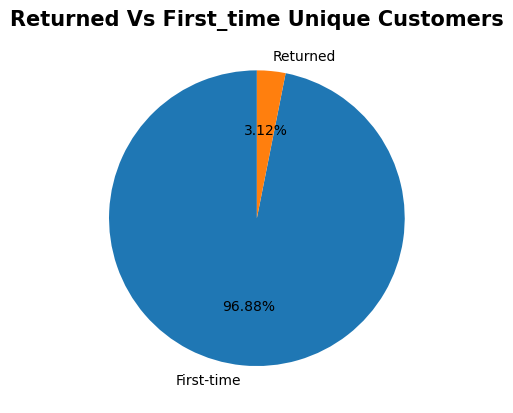

In [77]:
unique_customer_counts = df_customer['customer_unique_id'].value_counts()

customer_type_labels = unique_customer_counts.apply(lambda x: 'Returned' if x > 1 else 'First-time')

customer_type_distribution = customer_type_labels.value_counts()

plt.title("Returned Vs First_time Unique Customers",fontdict={'fontsize':15,'fontweight':600})
plt.pie(customer_type_distribution,normalize=True,startangle=90,
        labels=customer_type_distribution.index,autopct='%1.2f%%')
plt.show()

💡 Insight

- 약 96.88%의 고객이 첫 구매자이다.

- 재구매 고객은 3.12%에 불과해, 고객 충성도와 유지에 어려움이 있음을 시사한다.

- 구매 후 사용자 경험과 배송 신뢰도를 향상시키면 첫 구매 고객을 재구매 고객으로 전환하는 데 도움이 될 수 있다.

In [78]:
# 1. df_merged에서 주문 단위 중복 제거
#    주문별로 고객, 구매월, 주문금액만 남김
df_temp = df_merged[['order_id', 'customer_unique_id', 'purchase_month', 'total_order_value']] \
    .drop_duplicates(subset=['order_id']).copy()

# 2. purchase_month를 datetime으로 변환
df_temp['order_month'] = pd.to_datetime(df_temp['purchase_month'])

# 3. 고객별 첫 구매월 계산
df_temp['first_purchase_month'] = df_temp.groupby('customer_unique_id')['order_month'].transform('min')

# 4. 신규 고객 여부 판별
df_temp['is_new'] = df_temp['order_month'].eq(df_temp['first_purchase_month'])

# 5. 월별 신규 고객 수 / 신규 고객 매출
new_monthly = df_temp[df_temp['is_new']].groupby('order_month').agg(
    new_customers_count=('customer_unique_id', 'nunique'),
    new_customers_value=('total_order_value', 'sum')
)

# 6. 월별 재구매 고객 수
return_monthly = df_temp[~df_temp['is_new']].groupby('order_month').agg(
    return_customers_count=('customer_unique_id', 'nunique')
)

# 7. 월별 시계열 테이블 생성
data_customer_timeseries = pd.concat([new_monthly, return_monthly], axis=1) \
    .fillna(0).reset_index().rename(columns={'order_month': 'year_month'}) \
    .sort_values('year_month')

# 8. 표시용 문자열 변환
data_customer_timeseries['year_month'] = data_customer_timeseries['year_month'].dt.strftime('%Y-%m')

# 9. 시각화
fig = go.Figure()
fig.add_trace(go.Bar(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["new_customers_count"],
    name="Number of new customers",
    marker_color="mediumaquamarine"
))
fig.add_trace(go.Bar(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["return_customers_count"],
    name="Number of returned customers",
    marker_color="powderblue"
))
fig.add_trace(go.Scatter(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["new_customers_value"],
    name="Revenue from new customers",
    yaxis="y2",
    marker_color="indianred",
    mode="lines+markers"
))
fig.update_layout(
    title=dict(
        text="<b>New Customers And Return Customers By Month</b>",
        font=dict(size=12, family="Arial", color="black")
    ),
    plot_bgcolor="white",
    barmode="stack",
    yaxis=dict(side="left", showgrid=False, zeroline=True, showline=False, showticklabels=False),
    yaxis2=dict(side="right", overlaying="y", showgrid=False, zeroline=False, showline=False, showticklabels=False),
    xaxis=dict(showline=True, linecolor="rgb(204, 204, 204)", linewidth=2),
    legend=dict(orientation="h"),
    hovermode="x unified",
    annotations=[dict(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1.05, y=-0.25,
        showarrow=False,
        font=dict(size=10, color="gray", family="Arial")
    )]
)
fig.show(renderer="colab")

💡 Insight
- 2017년 신규 고객 유치에 큰 성공을 거두었으며 주요 매출원이 됨
- 2017년부터 2018년 초까지 신규 고객 수가 꾸준히 증가하다가 2018년 중반 이후 감소하는 경향을 보임
- 신규 고객으로부터 발생하는 매출이 전체 매출에 상당한 부분을 차지하고 있어, 신규 고객 확보가 매출 성장에 중요한 요소임을 알 수 있음


### 지역별 매출 분석
- 고객 지역(state)별 주문 수와 총 주문 금액(GMV)

In [79]:
# 1. 주문 단위 데이터만 남기기
df_state_orders = df_merged[['order_id', 'customer_state', 'total_order_value']].drop_duplicates(subset=['order_id']).copy()

# 2. 주(state) 기준 집계
df_customers_agg = df_state_orders.groupby('customer_state', as_index=False).agg(
    orders_count=('order_id', 'count'),
    total_value=('total_order_value', 'sum')
).rename(columns={'customer_state': 'location'}).sort_values('orders_count', ascending=False)

# 3. 상위 10개 지역만 추출
top10_states = df_customers_agg.head(10)

# 4. 시각화
fig = go.Figure()
fig.add_trace(go.Bar(
    x=top10_states['location'],
    y=top10_states['orders_count'],
    name='Number of orders',
    marker_color='rgb(64,224,208)'
))
fig.add_trace(go.Scatter(
    x=top10_states['location'],
    y=top10_states['total_value'],
    name='GMV',
    yaxis='y2',
    marker_color='rgb(255,160,122)',
    mode='lines+markers'
))
fig.update_layout(
    title=dict(
        text='<b>Top 10 Selling Geolocation</b>',
        font=dict(size=12, family='Arial', color='black')
    ),
    plot_bgcolor='white',
    yaxis=dict(
        side='left',
        range=[0, top10_states['orders_count'].max() + 1000],
        showgrid=False,
        zeroline=True,
        showline=False,
        showticklabels=False
    ),
    yaxis2=dict(
        side='right',
        overlaying='y',
        showgrid=False,
        zeroline=False,
        showline=False,
        showticklabels=False
    ),
    xaxis=dict(showline=True, linecolor='rgb(204, 204, 204)', linewidth=2),
    legend=dict(orientation='h', x=0.8, y=1.1),
    annotations=[dict(
        text='Created By Thuan Dao.',
        xref='paper', yref='paper',
        x=1, y=-0.45,
        showarrow=False,
        font=dict(size=10, color='gray', family='Arial')
    )],
    hovermode='x unified'
)
fig.show(renderer='colab')

💡 Insight
- 상파울루(SP)는 가장 많은 주문 건수와 가장 높은 총 판매액을 기록함.
- 리우데자네이루(RJ)와미나스제라이스(MG)는 판매 실적과 매출 기여도가 높은 것으로 나타남.

In [80]:
state_mapping = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia',
    'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás',
    'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais',
    'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí',
    'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo',
    'SE': 'Sergipe', 'TO': 'Tocantins'
}

legend_text = '<br>'.join([
    f"<b>{abbr}</b> → {name}"
    for abbr, name in sorted(state_mapping.items(), key=lambda x: x[1])
])

In [105]:
# 1. Prepare location coordinates from df_location
location_coords = df_location.groupby('geolocation_state').agg(
    lat=('geolocation_lat', 'median'),
    lng=('geolocation_lng', 'median')
).reset_index().rename(columns={'geolocation_state': 'customer_state'})

# 2. Prepare median payment per state from df_orders_unique
median_payment_data = df_orders_unique.groupby('customer_state')['total_order_value'].median().reset_index()
median_payment_data = median_payment_data.rename(columns={'total_order_value': 'median_payment'})

# 3. Start building state_group from df_customers_agg
state_group = df_customers_agg.rename(columns={'location': 'customer_state', 'orders_count': 'order_count'}).copy()

# 4. Merge median_payment_data into state_group
state_group = pd.merge(state_group, median_payment_data, on='customer_state', how='left')

# 5. Merge location_coords into state_group
state_group = pd.merge(state_group, location_coords, on='customer_state', how='left')

# Drop rows where essential plotting data (lat, lng, median_payment) might be missing after merges
state_group = state_group.dropna(subset=['lat', 'lng', 'median_payment'])

state_group['median_payment'] = state_group['median_payment'].round()

def assign_group(count):
    if count >= 5000:
        return 'Large (≥ 5000)'
    elif count >= 1000:
        return 'Medium (1000–4999)'
    else:
        return 'Small (< 1000)'

state_group['group'] = state_group['order_count'].apply(assign_group)

group_colors = {
    'Large (≥ 5000)': '#ef476f',
    'Medium (1000–4999)': '#ffd166',
    'Small (< 1000)': '#06d6a0'
}
group_sizes = {
    'Large (≥ 5000)': 20,
    'Medium (1000–4999)': 12,
    'Small (< 1000)': 7
}

state_group['color'] = state_group['group'].map(group_colors)
state_group['scaled_size'] = state_group['group'].map(group_sizes)

# Plotting the map
fig = px.scatter_geo(
    state_group,
    lat='lat',
    lon='lng',
    size='scaled_size',
    hover_name='customer_state',
    hover_data={
        'order_count': True,
        'median_payment': True,
        'lat': False,
        'lng': False
    },
    color='group',
    color_discrete_map=group_colors,
    projection='natural earth',
    title='Brazilian States: Median Payment and Order Volume',
    text=state_group['customer_state']
)

fig.add_annotation(
    text=legend_text,
    x=1.26,
    y=0.4,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=14, family="Courier New"),
    align="left",
    bgcolor="rgba(240, 240, 240,0.9)",
    bordercolor="gray",
    borderwidth=1.5
)

fig.update_layout(
    geo=dict(
        scope='south america',
        showland=True,
        landcolor='rgb(240, 240, 240)',
    ),
    height=750,
    width=900,
    legend_title_text='Order Volume Group'
)

fig.show(renderer='colab')

## 리뷰 분석

### 리뷰 점수 분포

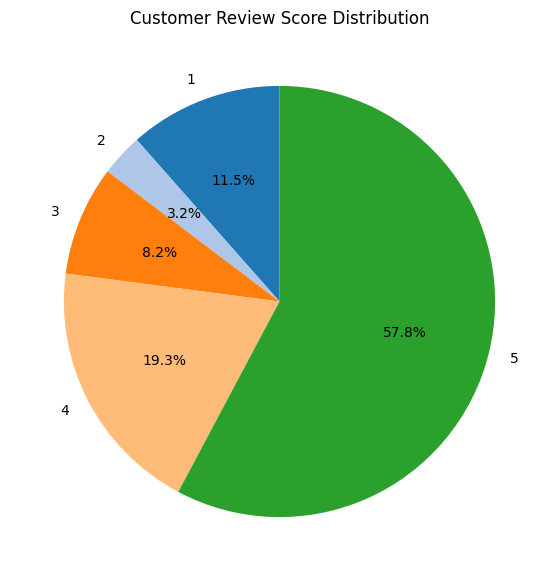

In [82]:
review_counts = df_order_review['review_score'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(review_counts, labels=review_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab20.colors)
plt.title('Customer Review Score Distribution')
plt.show()

💡 Insight
- 고객 10명 중 약 8명이 서비스에 만족(4점 이상)하고 있으며, 이는 전반적인 쇼핑 경험이 긍정적임을 의미한다.


- 부정적 리뷰의 비중을 줄이기 위해 지연 가능성이 높은 주문을 선제적으로 관리한다면 고객 충성도를 높이고 재구매율을 개선할 수 있다.

✔ 배송 지연 여부별 리뷰 평균



In [83]:
review_by_late = df_merged.groupby("is_late")["review_score"].agg(["mean","count","std"])
print(review_by_late)

             mean  count       std
is_late                           
0        4.261429  90453  1.181917
1        2.550772   7642  1.655787


배송 지연 여부(is_late)가 리뷰 점수(review_score)에 영향을 주는지 확인하기 위한 기초 통계 분석

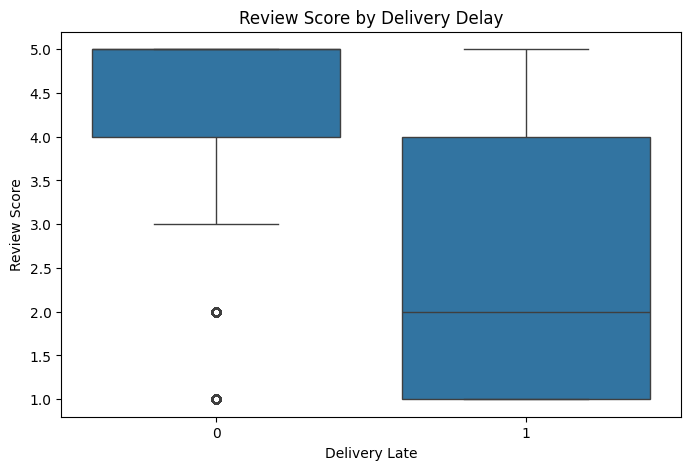

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_late",
    y="review_score",
    data=df_merged
)

plt.title("Review Score by Delivery Delay")
plt.xlabel("Delivery Late")
plt.ylabel("Review Score")
plt.show()

### 응답 시간 분포

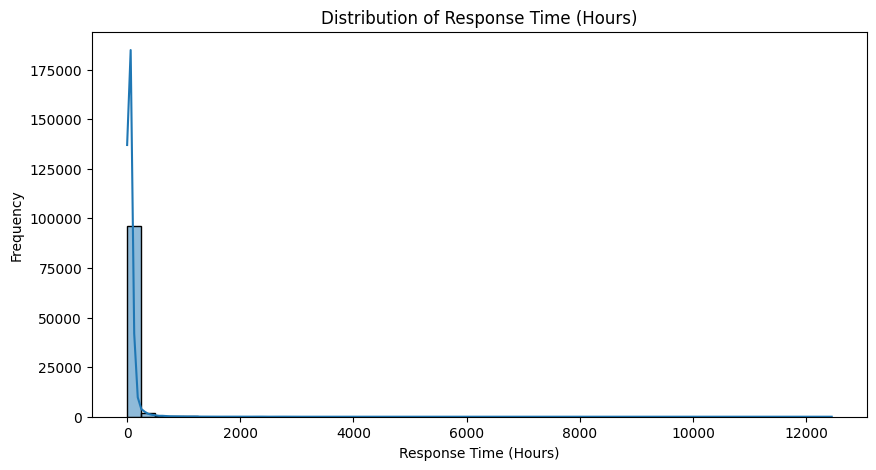

In [85]:
plt.figure(figsize=(10,5))
sns.histplot(df_order_review['response_time'].dt.total_seconds() / 3600, bins=50, kde=True)
plt.title("Distribution of Response Time (Hours)")
plt.xlabel("Response Time (Hours)")
plt.ylabel("Frequency")
plt.show()

## 시간대별 분석

### 월별 주문/배송시간 추이(Trend)

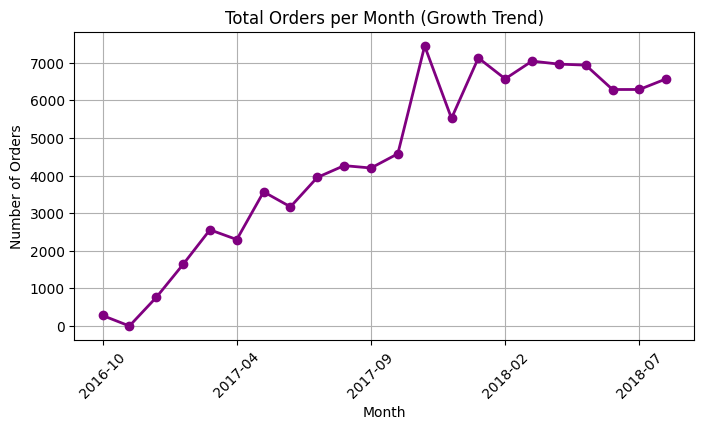

In [86]:
orders_per_month = df_merged.groupby('purchase_month')['order_id'].count()

plt.figure(figsize=(8, 4))
orders_per_month.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Total Orders per Month (Growth Trend)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

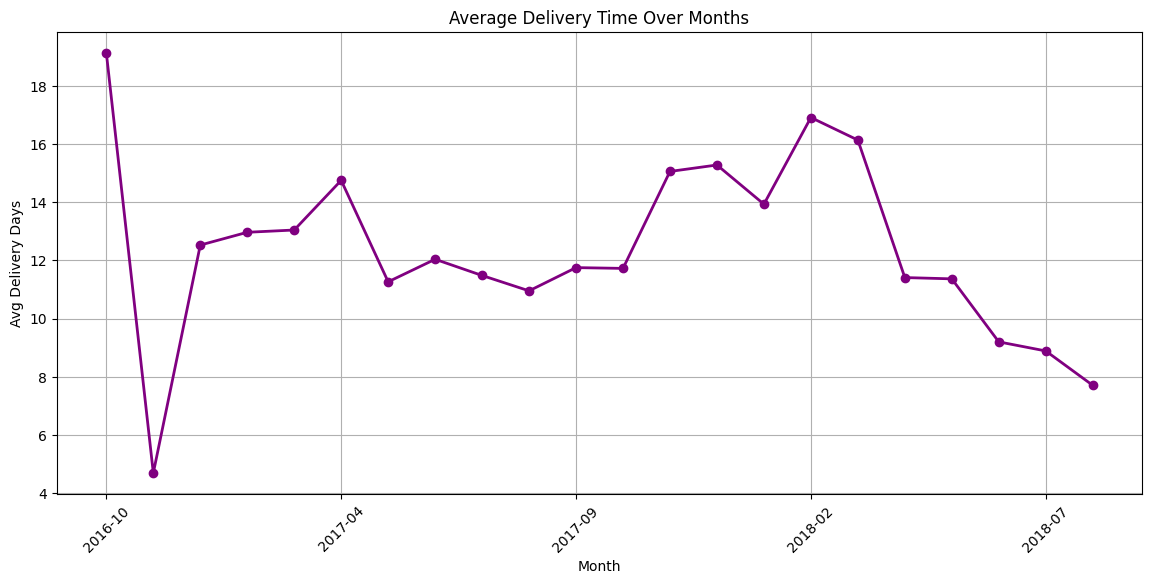

In [87]:
monthly_speed = df_merged.groupby('purchase_month')['delivery_days'].mean()

plt.figure(figsize=(14, 6))
monthly_speed.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Average Delivery Time Over Months')
plt.xlabel('Month')
plt.ylabel('Avg Delivery Days')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### 월별 지연 분석

In [88]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_orders = (
    df_merged
    .assign(Month=df_merged['order_approved_at'].dt.month_name())
    .groupby('Month')
    .agg(
        total_order=('order_id','nunique'), # Use nunique() to count each unique order_id in df_merged
        total_delays=('is_late','sum')    # Sum is correct as 'is_late' is per order (not item)
    )
    .reindex(month_order)
    .reset_index()
)

monthly_orders

,Month,total_order,total_delays
0,January,7466,459
1,February,7962,1039
2,March,9392,1633
3,April,8736,527
4,May,10316,695
5,June,9117,200
6,July,9723,367
7,August,10583,807
8,September,4076,214
9,October,4625,228


In [89]:
# 월별 주문 수 / 지연 주문 수 집계
monthly_orders = df_orders.groupby('purchase_month').agg(
    total_orders=('order_id', 'nunique'),
    total_delays=('is_late', 'sum')
).reset_index()

fig = go.Figure()

# 월별 주문 수 (Bar Chart)
fig.add_trace(
    go.Bar(
        x=monthly_orders['purchase_month'],
        y=monthly_orders['total_orders'],
        name='Total Orders',
        marker_color='rgb(64,224,208)'
    )
)

# 월별 배송 지연 수 (Line Chart), 두 번째 Y축 사용
fig.add_trace(
    go.Scatter(
        x=monthly_orders['purchase_month'],
        y=monthly_orders['total_delays'],
        name='Total Delays',
        mode='lines+markers',
        yaxis='y2',
        marker_color='indianred'
    )
)

fig.update_layout(
    title="Monthly Orders and Delays Trend",
    xaxis_title="Month",
    yaxis=dict(
        title="Number of Orders",
        side="left",
        showgrid=False,
        zeroline=True
    ),
    yaxis2=dict(
        title="Number of Delays",
        side="right",
        overlaying="y",
        showgrid=False,
        zeroline=True
    ),
    plot_bgcolor="white",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.1),
    hovermode="x unified"
)

fig.show(renderer="colab")

💡 Insight
- 5월에서 8월 사이에 주문이 정점을 찍으며, 연중 중반기에 강한 수요가 나타남.
- 2~3월에 배송 지연이 가장 많음.
- 후반부에는 주문량이 줄었음에도 불구하고, 11월에 지연이 급증하는 것을 확인할 수 있음 (아마도 블랙프라이데이 때문?)

### 요일별 지연 분석

In [90]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

day_orders = (
    df_merged
    .assign(Day_name=df_merged['order_approved_at'].dt.day_name())
    .groupby('Day_name')
    .agg(
        total_order=('order_id','count'),
        total_delay=('is_late','sum')
    )
    .reindex(day_order)
    .reset_index()
)

day_orders

,Day_name,total_order,total_delay
0,Monday,12856,1074
1,Tuesday,19000,1499
2,Wednesday,15507,1223
3,Thursday,15275,1082
4,Friday,14485,1213
5,Saturday,12056,905
6,Sunday,8916,646


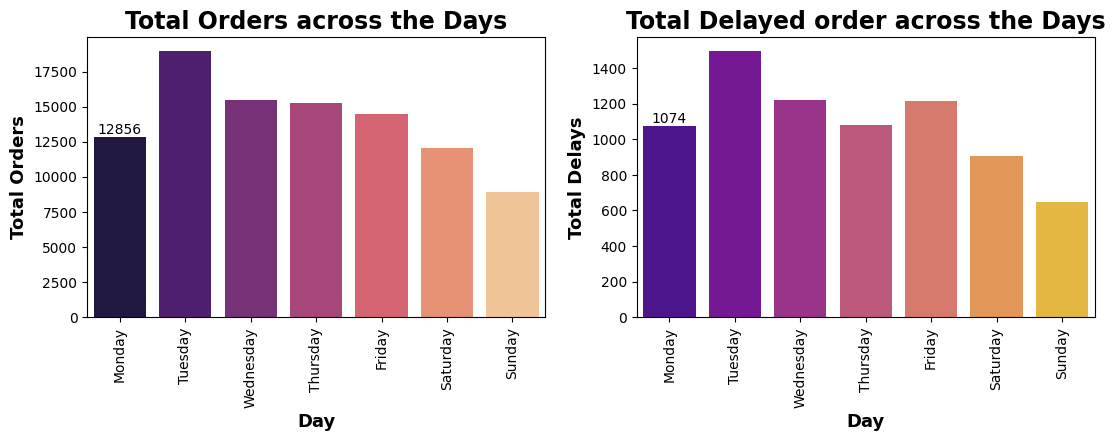

In [91]:
plt.figure(figsize=(13,8))
plt.subplot(2,2,1)
plt.title("Total Orders across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=day_orders,x='Day_name',y='total_order', palette="magma", hue='Day_name', legend=False)
ax.bar_label(ax.containers[0])
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Orders",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90);


plt.subplot(2,2,2)
plt.title("Total Delayed order across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=day_orders,x='Day_name',y='total_delay', palette="plasma", hue='Day_name', legend=False)
ax.bar_label(ax.containers[0])
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Delays",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90);
plt.show()

💡 Insight
- 화요일은 주문량과 지연 건수가 가장 많아, 주중 중반에 운영 과부하가 발생할 가능성이 있음
- 주말에는 주문이 적어 지연도 비교적 완만하게 유지됨.
- 이는 주 초반에 물류 및 운영 최적화가 가장 필요하다는 점을 보여줌.


### 시간대별 분석

In [92]:
# orders across the hours and Days
total_order=pd.pivot_table(data=df_merged,index=df_merged['order_approved_at'].dt.hour,
               columns=df_merged['order_approved_at'].dt.day_name(),values='order_id',aggfunc='count')
total_order

order_approved_at,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
order_approved_at,,,,,,,
0,312,248,251,239,295,296,309
1,289,151,297,172,240,170,192
2,1682,64,1739,97,1605,187,1605
3,791,30,712,35,978,1911,995
4,287,22,298,25,291,2103,294
5,99,11,102,19,153,594,56
6,86,68,108,46,115,300,194
7,273,126,90,73,221,488,190
8,381,303,178,123,391,468,387


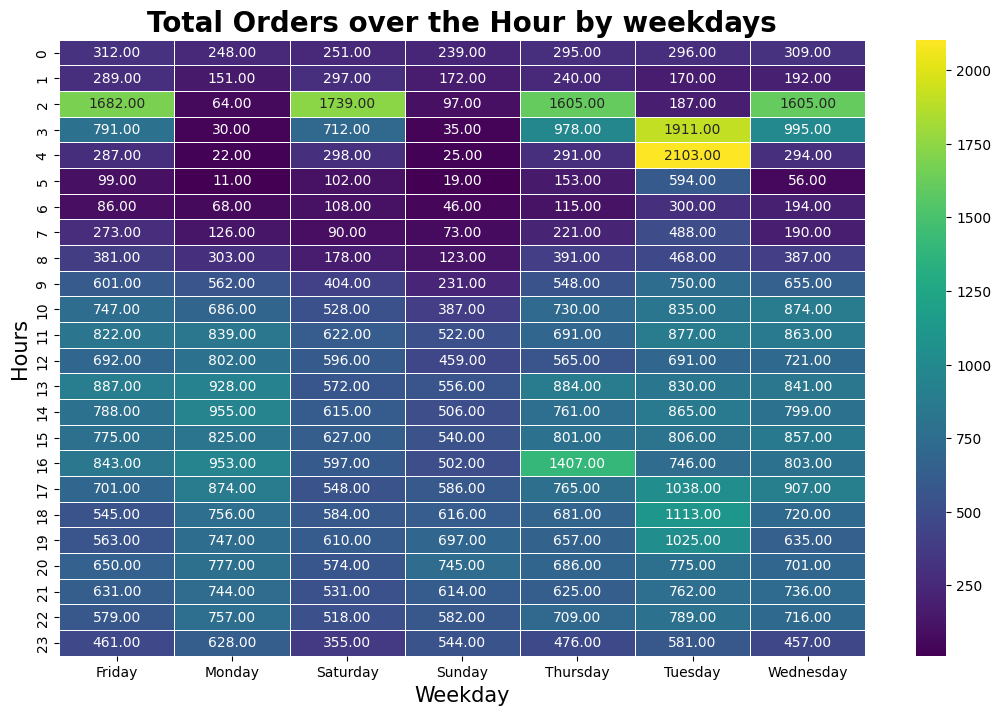

In [93]:
plt.figure(figsize=(13,8))
plt.title("Total Orders over the Hour by weekdays",fontdict={'fontsize':20,'fontweight':560})
sns.heatmap(data=total_order,annot=True,fmt='.2f',cmap="viridis",linecolor='white',linewidths=0.5)
plt.xlabel("Weekday",fontsize=15)
plt.ylabel("Hours",fontsize=15)
plt.show()

💡 Insight
- 대부분의 주문은 오전 10시부터 오후 4시 사이에 집중되어 있다.
- 이른 아침과 심야 시간대에는 주문이 상대적으로 적다. 이는 일반적인 소비자의 쇼핑 패턴과 일치한다.
- 새벽 3~4시 주문이 급증하는데, 주문 승인 시간(order_approved_at)의 영향일 수 있다.


### 배송 시간 분포

In [94]:
delay_rate = df_merged["is_late"].mean() * 100
print(f"배송 지연 확률: {delay_rate:.2f}%")

배송 지연 확률: 7.79%


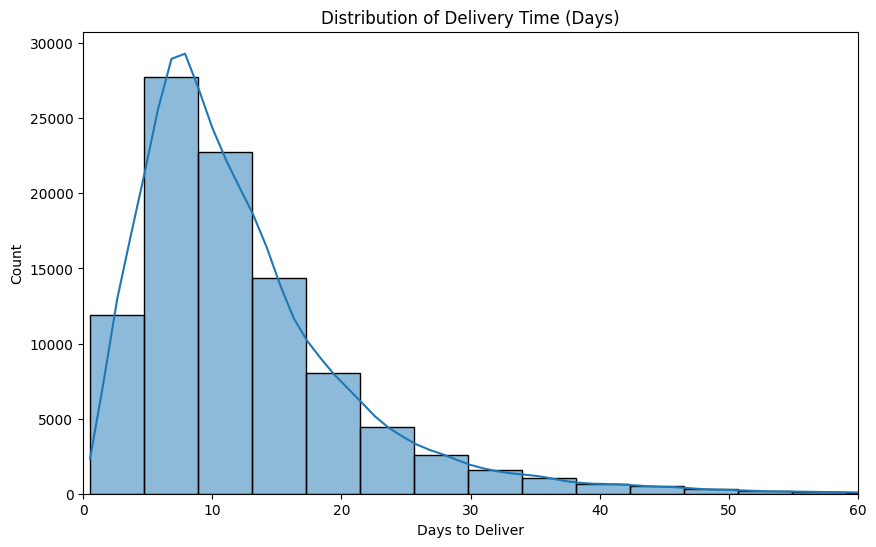

Average Delivery Time: 12.45 days


In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(df_orders['delivery_days'], bins=50, kde=True)
plt.title('Distribution of Delivery Time (Days)')
plt.xlabel('Days to Deliver')
plt.xlim(0, 60) # We're focusing on the first 60 days for the Outliers
plt.show()

print(f"Average Delivery Time: {df_merged['delivery_days'].mean():.2f} days")

## 지역 분석

In [96]:
State_delay_sumry=df_merged.groupby(['seller_state']).agg(delayed_order=('is_late','sum'),
                                   total_order=('is_late','count')).reset_index()
State_delay_sumry['delay%']=round((State_delay_sumry['delayed_order']/State_delay_sumry['total_order'])*100,2)
State_delay_sumry

,seller_state,delayed_order,total_order,delay%
0,AM,2,3,66.67
1,BA,31,550,5.64
2,CE,8,87,9.20
3,DF,50,802,6.23
4,ES,18,305,5.90
5,GO,18,459,3.92
6,MA,87,390,22.31
7,MG,414,7693,5.38
8,MS,3,48,6.25
9,MT,6,139,4.32


In [97]:
reg_delay=pd.pivot_table(data=df_merged,index='customer_state',columns='seller_state',values='is_late',aggfunc='sum',fill_value=0)
reg_delay



seller_state,AM,BA,CE,DF,ES,GO,MA,MG,MS,MT,PA,PB,PE,PI,PR,RJ,RN,RO,RS,SC,SE,SP
customer_state,,,,,,,,,,,,,,,,,,,,,,
AC,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
AL,1,0,0,0,0,0,3,5,0,0,0,1,1,0,14,2,0,0,0,0,0,65
AM,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5
AP,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
BA,0,6,1,2,1,0,2,37,1,0,0,0,0,0,23,13,1,0,7,10,0,343
CE,0,2,0,4,0,0,1,9,0,1,0,0,1,0,9,12,1,0,2,6,0,143
DF,0,0,0,3,0,2,5,6,0,0,0,0,1,0,6,8,0,0,1,1,0,112
ES,0,0,0,5,2,0,7,7,0,0,0,0,0,0,9,2,0,0,1,1,0,201
GO,0,0,0,1,0,1,6,4,0,0,0,0,0,0,3,4,0,0,0,5,0,126


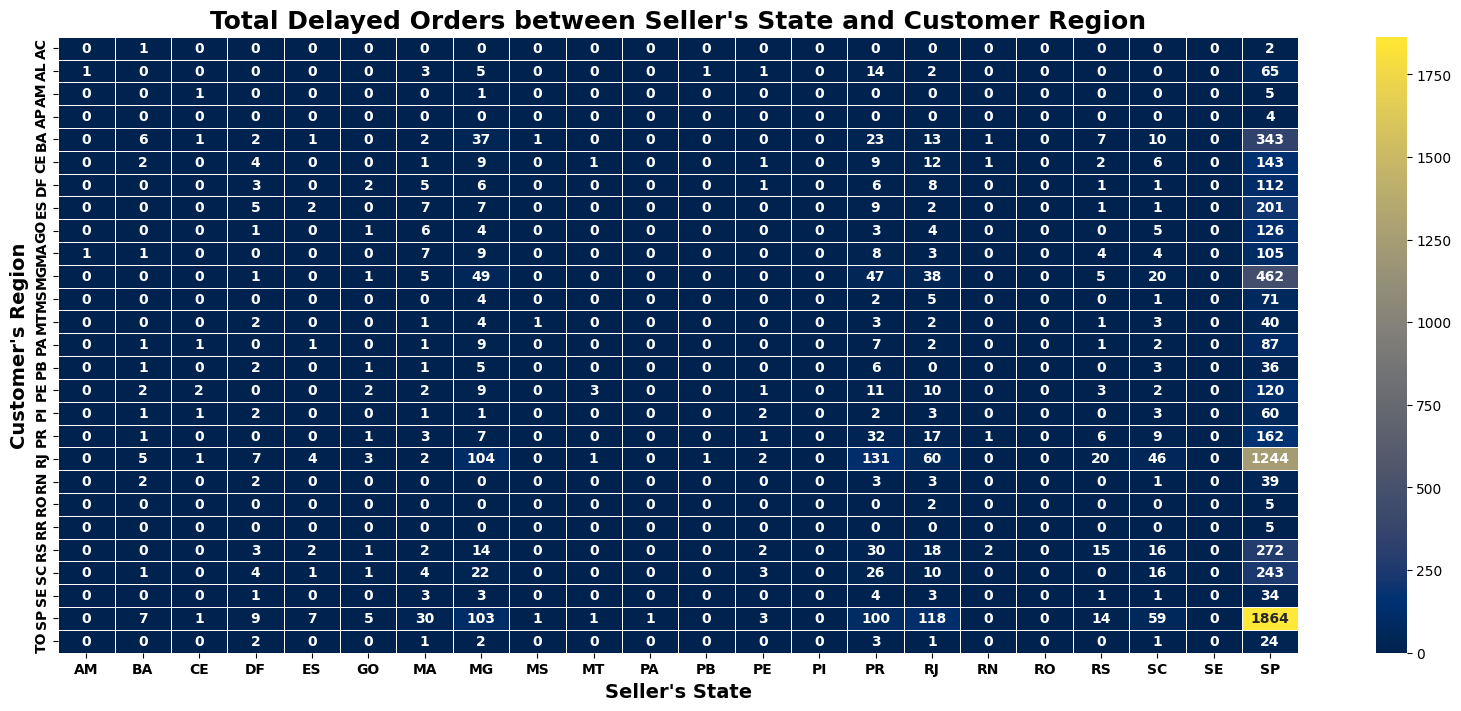

In [98]:
plt.figure(figsize=(20,8))
plt.title("Total Delayed Orders between Seller's State and Customer Region",
          fontdict={'fontsize':18,'fontweight':700})
sns.heatmap(data=reg_delay,annot=True,fmt='.0f',cmap="cividis",linecolor='white',
            linewidths=0.5,annot_kws={"weight": "bold"})
plt.xlabel("Seller's State",fontdict={'fontsize':14,'fontweight':600})
plt.xticks(fontweight=600)
plt.ylabel("Customer's Region",fontdict={'fontsize':14,'fontweight':600})
plt.yticks(fontweight=600)
plt.show()

💡 Insight
- 상파울루(SP) 판매자와 동남부 고객 간에 가장 높은 지연이 발생한다.
- 상파울루는 브라질 물류의 중심지로 거래량이 가장 많기 때문에 절대적인 지연 건수도 높게 나타난다.
- 몇몇 주를 제외하고는 Inter-state가 활발하지 않거나, 특정 루트에서만 배송 사고가 집중됨을 시사한다.

## 결제 방식 분석

In [99]:
df_order_payment['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


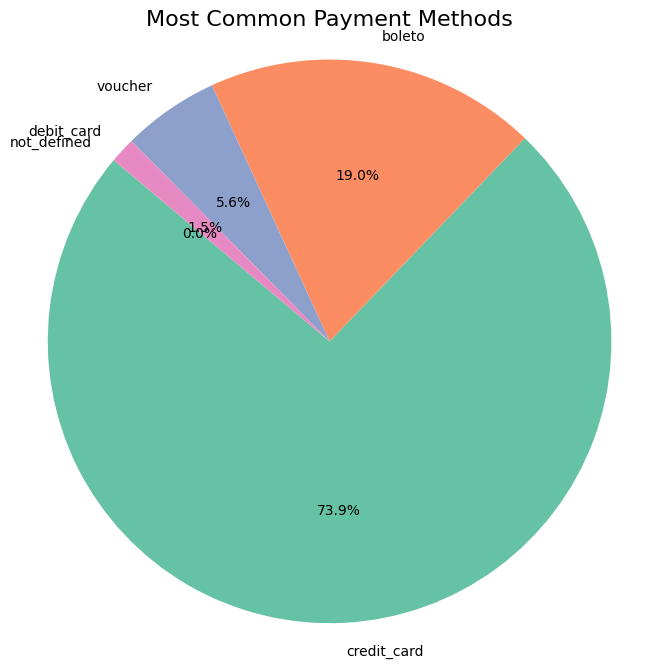

In [100]:
payment_counts = df_order_payment['payment_type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(payment_counts.values, labels=payment_counts.index,
        autopct='%1.1f%%',startangle=140, colors=sns.color_palette("Set2"))
plt.title("Most Common Payment Methods", fontsize=16)
plt.axis('equal')
plt.show()

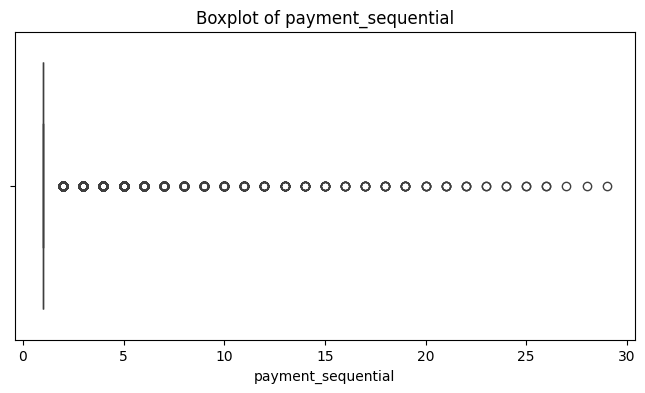

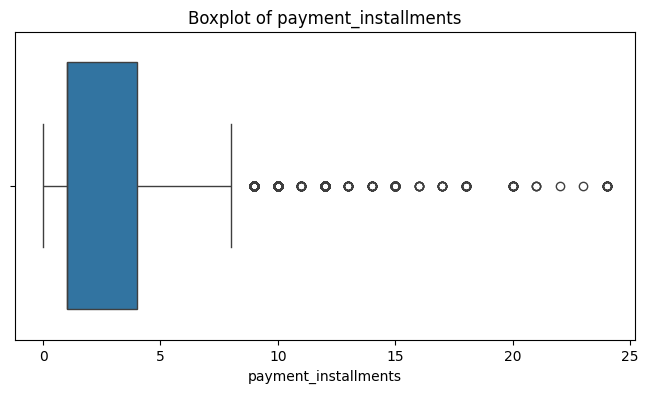

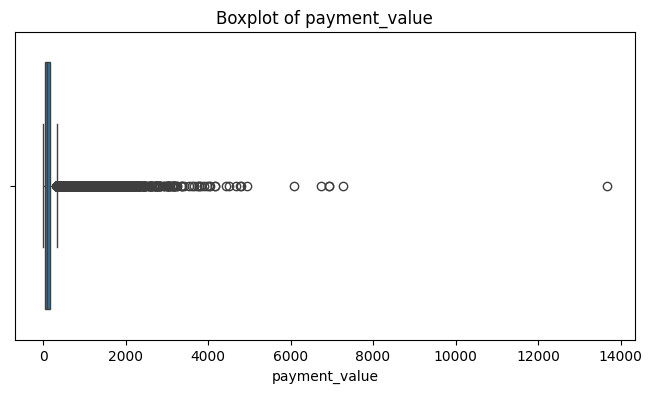

In [101]:
num_col = df_order_payment.select_dtypes(['int64' , 'float64']).columns
for col in num_col:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_order_payment, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

일부 고가 주문이 존재하며 결제 금액 분포는 왼쪽으로 치우친 형태이다.

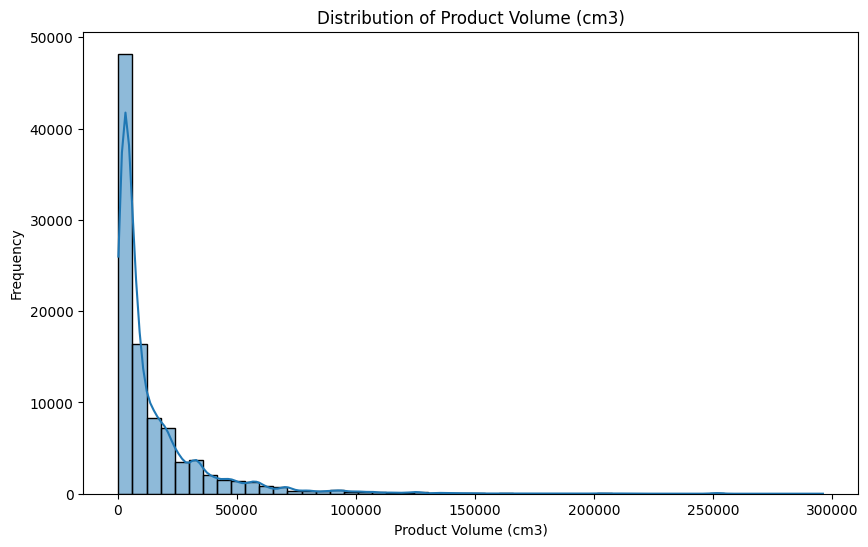

In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['product_volume_cm3'], bins=50, kde=True)
plt.title('Distribution of Product Volume (cm3)')
plt.xlabel('Product Volume (cm3)')
plt.ylabel('Frequency')
plt.show()

# 7️⃣ Machine Modeling




## Regression Models

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from imblearn.pipeline import Pipeline
import numpy as np
import joblib

features = ['price', 'freight_value', 'estimated_duration']
cat_cols = ['product_category_name_english', 'customer_state', 'seller_state']

df_merged['estimated_duration'] = (
    df_merged['order_estimated_delivery_date'] - df_merged['order_purchase_timestamp']
).dt.days

x = df_merged[features + cat_cols].copy()
y = df_merged['delivery_days']

# 결측치 처리
x[cat_cols] = x[cat_cols].fillna('Unknown')
x[features] = x[features].fillna(0)
y = y.fillna(0)

try:
    cat_transform = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    cat_transform = OneHotEncoder(handle_unknown='ignore', sparse=False)

preproc = ColumnTransformer([
    ('num', 'passthrough', features),
    ('cat', cat_transform, cat_cols)
])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=24,
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([
    ('preprocessor', preproc),
    ('model', reg)
])

pipe.fit(x_train, y_train)

joblib.dump(pipe, "delivery_days_regression_model.pkl")
print("\n📂📂📂 Model is saved.")
print("-" * 120)

pred = pipe.predict(x_test)
train_pred = pipe.predict(x_train)

print("\nRegression Metrics:")
print(f"MAE       : {mean_absolute_error(y_test, pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, pred)):.4f}")
print(f"R2 Score  : {r2_score(y_test, pred):.4f}")
print(f"Train Score : {pipe.score(x_train, y_train):.4f}")
print(f"Test Score  : {pipe.score(x_test, y_test):.4f}")
print("_" * 120)


📂📂📂 Model is saved.
------------------------------------------------------------------------------------------------------------------------

Regression Metrics:
MAE       : 5.0483
RMSE      : 8.2848
R2 Score  : 0.2402
Train Score : 0.6998
Test Score  : 0.2402
________________________________________________________________________________________________________________________


## Predictive Models

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline
import joblib

features = ['price', 'freight_value', 'total_order_value', 'estimated_duration', 'product_volume_cm3']
cat_cols = ['product_category_name_english', 'customer_state', 'seller_state', 'purchase_day_of_week']

df_merged['estimated_duration'] = (
    df_merged['order_estimated_delivery_date'] - df_merged['order_purchase_timestamp']
).dt.days

x = df_merged[features + cat_cols].copy()
y = df_merged['is_late']

# 결측치 처리
x[cat_cols] = x[cat_cols].fillna('Unknown')
x[features] = x[features].fillna(0)

try:
    cat_transform = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    cat_transform = OneHotEncoder(handle_unknown='ignore', sparse=False)

preproc = ColumnTransformer([
    ('num', 'passthrough', features),
    ('cat', cat_transform, cat_cols)
])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=24,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([
    ('preprocessor', preproc),
    ('model', clf)
])

pipe.fit(x_train, y_train)

joblib.dump(pipe, "delay_prediction_model.pkl")
print("\n📂📂📂 Model is saved.")
print("-" * 120)

pred = pipe.predict(x_test)
pred_proba = pipe.predict_proba(x_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))
print(f"ROC-AUC : {roc_auc_score(y_test, pred_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, pred_proba):.4f}")
print(f"Train Score : {pipe.score(x_train, y_train):.4f}")
print(f"Test Score  : {pipe.score(x_test, y_test):.4f}")
print("_" * 120)


📂📂📂 Model is saved.
------------------------------------------------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     22613
           1       0.22      0.28      0.25      1911

    accuracy                           0.87     24524
   macro avg       0.58      0.60      0.59     24524
weighted avg       0.88      0.87      0.88     24524

ROC-AUC : 0.7093
PR-AUC  : 0.1880
Train Score : 0.9318
Test Score  : 0.8685
________________________________________________________________________________________________________________________
